In [1]:
#run only once!
%load_ext autoreload
%autoreload 2
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

In [71]:
import numpy as np
from phidl import LayerSet
from phidl import quickplot as qp
from phidl import Path, CrossSection, Device
import phidl.path as pp
import phidl.geometry as pg
import phidl
import matplotlib.pyplot as plt
# from deprecated.Bertram_Functions.MyPhidlFunctions import *
from Schuster_Resonators.resonator import ChipResonatorsTline, ChipTline, ChipResonatorsTwoTlines, InductorSection
from Schuster_Resonators.approx_Schuster import *
from CPW.cpw import *

In [ ]:
# params of uGe NbTiN resonators (SiRes-12phsq-v3)
# SeparationTlineResonator12 = [0]*7 + [5,0,10,0,10]
# NumberOfResonators12 = 6

# #Resonator parameters
# CapacitorHorizontalLength12 = np.ones(NumberOfResonators12)*150
# CapacitorVerticalLength12 = np.ones(NumberOfResonators12)*100
# CapacitorWidth12 = np.ones(NumberOfResonators12)*5

# NumberOfBends12 = np.ones(NumberOfResonators12, dtype=int)*[ 6, 6, 8, 9, 11, 14]
# InductorVerticalLength12 = np.ones(NumberOfResonators12)*5
# InductorHorizontalLength12 = np.ones(NumberOfResonators12)*[ 62,  78,  75,  82,  90,  100] 
# InductorEndLength12 = np.ones(NumberOfResonators12)*( [55,55] + [50] + [90]*3)
# InductorTotalLength12 = InductorVerticalLength12*(NumberOfBends12+4) + InductorEndLength12 +InductorHorizontalLength12*(NumberOfBends12+1)
# InductorWidth12 = np.ones(NumberOfResonators12)*0.6
# TaperWidth12 = np.ones(NumberOfResonators12)*20

# SpacingC012 = np.ones(NumberOfResonators12)*5
# # SpacingCc12 = np.ones(NumberOfResonators12)*np.sort(np.linspace(136,0,6))
# SpacingCc12 = np.ones(NumberOfResonators12)*[136]
# TaperLength12 = np.ones(NumberOfResonators12)*5
# FinalSpacingBondpads12 = 100

# FeedlineWidth12 = 80
# FeedlineLength12  = 2800
# FeedlineGap12 = 50
# FeedlineTaperLength12 =  100
# BondpadWidth12 =  200
# BondpadLength12 = 400
# BondpadGap12 = BondpadWidth12*(FeedlineGap12/FeedlineWidth12)
# ChipSize12 = [FeedlineLength12 + 2*BondpadLength12 + 2*FeedlineTaperLength12 + 2*FinalSpacingBondpads12, 2000]


# added inductor design

In [7]:
def InductorSectiontoJJ(NumberOfBends, 
                    InductorVerticalLength,
                    InductorHorizontalLength,
                    EndLength,
                    InductorWidth):
    '''
    Creates the inductor section of the Schuster resonator. It has a S-shape.
    Origin defined on the top of the inductor
    Parameters:
    - NumberOfBends: Number of bends in the inductor
    - InductorVerticalLength: Vertical length of the inductor bend. It is the vertical length of the S-shape
    - InductorHorizontalLength: Horizontal length of the inductor bend. It is the horizontal length of the S-shape
    - EndLength: Length of the straight section at the end of the inductor, which connects to ground
    - InductorWidth: Width of the inductor
    '''
    
    #Create a path for the inductor. Origin defined on the top of the inductor
    #Which will be connected to the port of the CapacitorSection
    points = [(0,0), (0, -InductorVerticalLength)]
    # Add points of the bend. Each bend is composed of 4 points that make an S-shape
    for i in range(NumberOfBends):
        direction = (-1)**(i+1)
        points.append((-InductorHorizontalLength/2*direction, -InductorVerticalLength*(i+1)))
        points.append((-InductorHorizontalLength/2*direction, -InductorVerticalLength*(i+2)))
        points.append((0, -InductorVerticalLength*(i+2)))
    points.append((0, -InductorVerticalLength*(NumberOfBends+2) - EndLength)) 
    StraightLength = InductorVerticalLength*(NumberOfBends+2) + EndLength
    PathInductor = pp.smooth(points, radius = InductorWidth*1)

    PolyInductor = PathInductor.extrude(width = InductorWidth, simplify=1e-3, layer = 0)
    PolyInductor.add_port(name = 'Top', midpoint=(0, 0), orientation = 90, width = InductorWidth)
    print(type(PolyInductor.get_polygons()[0]))
    return PolyInductor, StraightLength, points

## V1

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<class 'numpy.ndarray'>


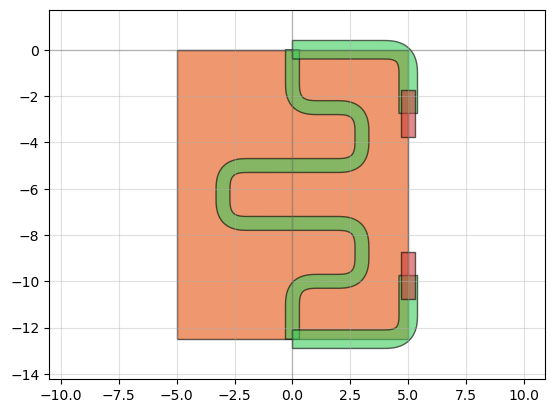

Design Vertical Length =  12.5
Inductor Total Length =  46.0
Inductance Ls = 0.8425000000000001  nH
Inductance Ls only meander = 0.6100000000000001  nH
total Area = 55.0


In [16]:
D = Device('InductorSection')

NumberOfBends = 3
InductorVerticalLength = 2.5
InductorHorizontalLength = 6
EndLength = 0
InductorWidth = 0.6
InductorTotalLength = InductorVerticalLength*(NumberOfBends+2) + EndLength + InductorHorizontalLength*(NumberOfBends)



I, L, pointsI = InductorSectiontoJJ(NumberOfBends, 
                    InductorVerticalLength,
                    InductorHorizontalLength,
                    EndLength,
                    InductorWidth)
xJJ = 5
yJJ = -L/2
totlengthJJ = 7  #defines the gap of first nbtin layer where the JJ or ASQ should be located

points = [(0,0), (xJJ,0), (xJJ,yJJ+totlengthJJ/2)]
# points = [(0,0), (xJJ,0), (xJJ, -InductorVerticalLength), (xJJ -InductorHorizontalLength/2, -InductorVerticalLength), (xJJ,yJJ)]
AdditionalPathInductor = pp.smooth(points, radius = InductorWidth*1)
AdditionalPolyInductor = AdditionalPathInductor.extrude(width = InductorWidth+0.2, simplify=1e-3, layer = 0)
I.add(AdditionalPolyInductor)

points = [(0,-L), (xJJ,-L), (xJJ,yJJ-totlengthJJ/2)]
AdditionalPathInductor = pp.smooth(points, radius = InductorWidth*1)
AdditionalPolyInductor = AdditionalPathInductor.extrude(width = InductorWidth+0.2, simplify=1e-3, layer = 0)
I.add(AdditionalPolyInductor)
box = pg.rectangle(size=(xJJ*2, L), layer=1).movex(-xJJ).movey(-L)
D.add_polygon(box.get_polygons(), layer=11)
D.add_polygon(I.get_polygons(), layer=12)


#connecting parts to the JJ or ASQ leads
nbtin_overlap_w = 0.6
nbtin_overlap_h = 2
nbtin_overlap = pg.rectangle(size=(nbtin_overlap_w, nbtin_overlap_h),layer = 14).move([xJJ-nbtin_overlap_w/2,(yJJ - totlengthJJ/2 - nbtin_overlap_h/2)])
D.add_polygon(nbtin_overlap.get_polygons(), layer=14)
nbtin_overlap = pg.rectangle(size=(nbtin_overlap_w, nbtin_overlap_h),layer = 14).move([xJJ-nbtin_overlap_w/2,(yJJ + totlengthJJ/2 - nbtin_overlap_h/2)])
D.add_polygon(nbtin_overlap.get_polygons(), layer=14)

#plotting and saving the design to gds file
qp(D)

D.write_gds('20260805-uGeRes-12phsq-added-Inductor\\gds\\InductorSection.gds')

print('Design Vertical Length = ', L)
print('Inductor Total Length = ', InductorTotalLength + 2*xJJ + L - totlengthJJ )
print('Inductance Ls =', 12e-12*((InductorTotalLength)/0.6 + (2*xJJ +L - totlengthJJ)/0.8)*1e9, ' nH')
print('Inductance Ls only meander =', 12e-12*((InductorTotalLength)/0.6 )*1e9, ' nH')
print("total Area =", np.abs(L*xJJ) - InductorVerticalLength*InductorHorizontalLength/2)


## V2 here we place the JJ at the y axis and the inductor around it, this way we get more Lk

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<class 'numpy.ndarray'>


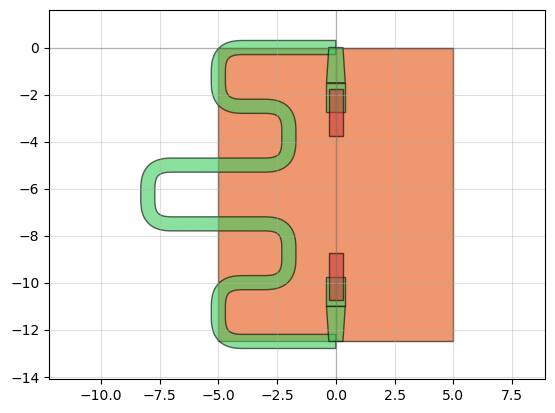

'20260805-uGeRes-12phsq-added-Inductor\\gds\\InductorSectionV2.gds'

In [204]:
D = Device('InductorSection')

NumberOfBends = 3
InductorVerticalLength = 2.5
InductorHorizontalLength = 6
EndLength = 0
InductorWidth = 0.6
InductorTotalLength = InductorVerticalLength*(NumberOfBends+2) + EndLength + InductorHorizontalLength*(NumberOfBends)
xJJ = 5
yJJ = -L/2
totlengthJJ = 7  #defines the gap of first nbtin layer where the JJ or ASQ should be located
nbtin_overlap_w = 0.6
nbtin_overlap_h = 2



_, L, pointsI = InductorSectiontoJJ(NumberOfBends, 
                    InductorVerticalLength,
                    InductorHorizontalLength,
                    EndLength,
                    InductorWidth)


pointsI.append((xJJ, -L))
pointsI.insert(0, (xJJ,0))
AdditionalPathInductor = pp.smooth(pointsI, radius = InductorWidth*1)
I = AdditionalPathInductor.extrude(width = InductorWidth, simplify=1e-3, layer = 0)
I.move((-xJJ,0))

tapert = pg.taper(length = 1.5, width1 = 0.6, width2 = .8)
tapert.rotate(-90)
taperendt = pg.rectangle(size=(.8, (L - 1.5*2 - totlengthJJ)/2)).move([-.4, -1.5-(L - 1.5*2 - totlengthJJ)/2])

taperb = pg.taper(length = 1.5, width1 = 0.6, width2 = .8)
taperb.rotate(90)
taperb.movey(-L)
taperendb = pg.rectangle(size=(.8, (L - 1.5*2 - totlengthJJ)/2)).move([-.4, -L+1.5])

box = pg.rectangle(size=(xJJ*2, L), layer=1).movex(-xJJ).movey(-L)
D.add_polygon(box.get_polygons(), layer=11)
D.add_polygon(I.get_polygons(), layer=12)
D.add_polygon(tapert.get_polygons(), layer=12)
D.add_polygon(taperendt.get_polygons(), layer=12)
D.add_polygon(taperb.get_polygons(), layer=12)
D.add_polygon(taperendb.get_polygons(), layer=12)

#connecting parts to the JJ or ASQ leads
nbtin_overlap = pg.rectangle(size=(nbtin_overlap_w, nbtin_overlap_h),layer = 14).move([-1*nbtin_overlap_w/2,(yJJ - totlengthJJ/2 - nbtin_overlap_h/2)])
D.add_polygon(nbtin_overlap.get_polygons(), layer=14)
nbtin_overlap = pg.rectangle(size=(nbtin_overlap_w, nbtin_overlap_h),layer = 14).move([-1*nbtin_overlap_w/2,(yJJ + totlengthJJ/2 - nbtin_overlap_h/2)])
D.add_polygon(nbtin_overlap.get_polygons(), layer=14)

#plotting and saving the design to gds file
qp(D)

D.write_gds('20260805-uGeRes-12phsq-added-Inductor\\gds\\InductorSectionV2.gds')




In [205]:
print('Design Vertical Length = ', L)
print('Inductor Total Length = ', InductorTotalLength + 2*xJJ + L - totlengthJJ )
print('Inductance Ls =', 12e-12*((InductorTotalLength)/0.6 + (2*xJJ)/0.6)*1e9, ' nH')
print("total Area =", np.abs(L*xJJ) - InductorVerticalLength*InductorHorizontalLength/2)

Design Vertical Length =  12.5
Inductor Total Length =  46.0
Inductance Ls = 0.8099999999999999  nH
total Area = 55.0


## Resonator design

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


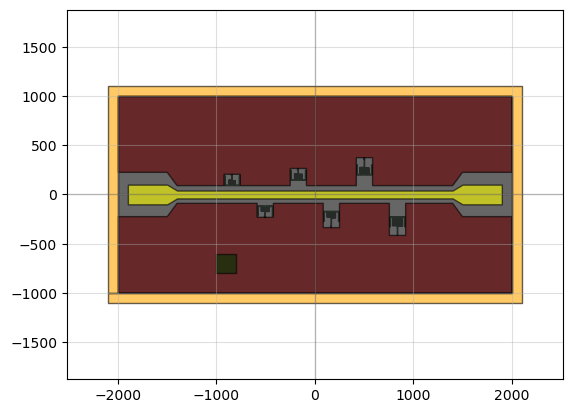

'20260805-uGeRes-12phsq-added-Inductor\\gds\\20260805-uGeRes-12pHsq-added-inductorV2.gds'

In [206]:
SeparationTlineResonator12 = [0]*7
NumberOfResonators12 = 6

#Resonator parameters
CapacitorHorizontalLength12 = np.ones(NumberOfResonators12)*150
CapacitorVerticalLength12 = np.ones(NumberOfResonators12)*100
CapacitorWidth12 = np.ones(NumberOfResonators12)*5

NumberOfBends12 = np.ones(NumberOfResonators12, dtype=int)*[ 6, 6, 8, 9, 11, 14]
InductorVerticalLength12 = np.ones(NumberOfResonators12)*5
InductorHorizontalLength12 = np.ones(NumberOfResonators12)*[ 62,  78,  75,  82,  90,  100] 
InductorEndLength12 = np.ones(NumberOfResonators12)*( [55,55] + [50] + [90]*3)
InductorTotalLength12 = InductorVerticalLength12*(NumberOfBends12+4) + InductorEndLength12 +InductorHorizontalLength12*(NumberOfBends12+1)
InductorWidth12 = np.ones(NumberOfResonators12)*0.6
TaperWidth12 = np.ones(NumberOfResonators12)*20

SpacingC012 = np.ones(NumberOfResonators12)*5
SpacingCc12 = np.ones(NumberOfResonators12)*np.sort(np.linspace(136,0,6))
TaperLength12 = np.ones(NumberOfResonators12)*5
FinalSpacingBondpads12 = 100

FeedlineWidth12 = 80
FeedlineLength12  = 2800
FeedlineGap12 = 50
FeedlineTaperLength12 =  100
BondpadWidth12 =  200
BondpadLength12 = 400
BondpadGap12 = BondpadWidth12*(FeedlineGap12/FeedlineWidth12)
ChipSize12 = [FeedlineLength12 + 2*BondpadLength12 + 2*FeedlineTaperLength12 + 2*FinalSpacingBondpads12, 2000]

c, metal, chip12 = ChipResonatorsTline(ChipSize12, NumberOfResonators12, SeparationTlineResonator12,
                        FeedlineWidth12, FeedlineLength12, FeedlineGap12, 
                        FeedlineTaperLength12, BondpadWidth12, BondpadLength12, BondpadGap12,
                        CapacitorHorizontalLength12, CapacitorVerticalLength12, CapacitorWidth12,
                        NumberOfBends12, InductorVerticalLength12, InductorHorizontalLength12, InductorWidth12, InductorEndLength12,
                        TaperWidth12, TaperLength12, SpacingC012, SpacingCc12,
                        FinalSpacingBondpads12, MWO_simulation=False)



#add the inductor part
InductorLooptoGND = 5
EdgeResDistanceFactor = 0.3
xpos_inductors = np.linspace(-EdgeResDistanceFactor*FeedlineLength12, EdgeResDistanceFactor*FeedlineLength12, NumberOfResonators12)
sign = 1

for i in range(NumberOfResonators12-1):
    temp = Device('temp') 
    temp << D
    ypos = sign*(FeedlineWidth12/2 + FeedlineGap12 + SeparationTlineResonator12[i] 
                     + SpacingCc12[i] + CapacitorWidth12[i] +TaperLength12[i]
                     + InductorVerticalLength12[i]*(NumberOfBends12[i]+4) + InductorEndLength12[i]-InductorLooptoGND - L/2)
    temp.movey(L/2)
    temp.move(origin = (0,0), destination = (xpos_inductors[i], ypos))
    chip12 << temp
    chip12.flatten()
    sign *= -1

ResonatorDesigns = pg.extract(chip12, layers = [(4,0)])
addedInductor = pg.extract(chip12, layers = [(12,0)])
Box = pg.extract(chip12, layers = [(11,0)])
adapted_metal = pg.boolean(ResonatorDesigns, Box, operation = 'A-B', layer = 12)
adapted_metal = pg.boolean(adapted_metal, addedInductor, operation = 'A+B', layer = 12)

layer12 = Device('layer12')
layer12.add_polygon(adapted_metal.get_polygons())
layer12 = pg.union(layer12, layer = 12)

chip12.remove_layers(layers = [(4,0), (11,0), (12,0)])
chip12.add_ref(layer12)
chip12.flatten()



qp(chip12)



chip12.write_gds("20260805-uGeRes-12phsq-added-Inductor\\gds\\20260805-uGeRes-12pHsq-added-inductorV2.gds")

In [199]:
Lk = 10e-12#12e-12#12e-12
epsilon_r = [16]
thickness_subs = [525e-6]
FeedlineWidth = 22
FeedlineLength  = 2800
FeedlineGap = 4
FeedlineTaperLength =  100
BondpadWidth =  200
BondpadLength = 400
BondpadGap = BondpadWidth*(FeedlineGap/FeedlineWidth)

print('Impedance of the feedline is', impedance_CPW(FeedlineWidth*1e-6, FeedlineGap*1e-6, epsilon_r, thickness_subs, ind_kin_sq=Lk), 'Ohm')
print('Frequency of the feedline is', resonance_freq_CPW(FeedlineWidth*1e-6, FeedlineGap*1e-6, epsilon_r, thickness_subs, ind_kin_sq=Lk, length_CPW=(FeedlineLength + FeedlineTaperLength + BondpadLength)*1e-6)/1e9, 'GHz')

Impedance of the feedline is 49.17815645269306 Ohm
Frequency of the feedline is 3.134189294246665 GHz


In [155]:
Lk = 1.8e-12
epsilon_r = [16]
thickness_subs = [525e-6]
FeedlineWidth = 80
FeedlineLength  = 2800
FeedlineGap = 50
FeedlineTaperLength =  100
BondpadWidth =  200
BondpadLength = 400
BondpadGap = BondpadWidth*(FeedlineGap/FeedlineWidth)

print('Impedance of the feedline is', impedance_CPW(FeedlineWidth*1e-6, FeedlineGap*1e-6, epsilon_r, thickness_subs, ind_kin_sq=Lk), 'Ohm')
print('Frequency of the feedline is', resonance_freq_CPW(FeedlineWidth*1e-6, FeedlineGap*1e-6, epsilon_r, thickness_subs, ind_kin_sq=Lk, length_CPW=(FeedlineLength + FeedlineTaperLength + BondpadLength)*1e-6)/1e9, 'GHz')

Impedance of the feedline is 46.93352900734288 Ohm
Frequency of the feedline is 4.850054166967093 GHz
